In [93]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier  
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV 
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [94]:
all_sheets = pd.read_excel(r"c:\Users\DELL\Graduation project\Customer_Churn_Data_Large.xlsx", sheet_name=None)


In [95]:
xls = pd.ExcelFile("Customer_Churn_Data_Large.xlsx")

#sheet list
xls.sheet_names

['Customer_Demographics',
 'Transaction_History',
 'Customer_Service',
 'Online_Activity',
 'Churn_Status']

In [96]:
import pandas as pd

# 1. قراءة كل الشيتات مرة واحدة في قاموس (Dictionary)
all_sheets = pd.read_excel("Customer_Churn_Data_Large (4).xlsx", sheet_name=None)

# 2. دمج الشيتات كلها بناءً على عمود CustomerID
# سنبدأ بأول شيت ثم ندمج الباقي عليه
sheets_names = list(all_sheets.keys())
df = all_sheets[sheets_names[0]]

for name in sheets_names[1:]:
    df = pd.merge(df, all_sheets[name], on="CustomerID", how="outer")

# الآن df تحتوي على كل البيانات من كل الشيتات
print(df.head())


   CustomerID  Age Gender MaritalStatus IncomeLevel  TransactionID  \
0           1   62      M        Single         Low           7194   
1           2   65      M       Married         Low           7250   
2           2   65      M       Married         Low           9660   
3           2   65      M       Married         Low           2998   
4           2   65      M       Married         Low           1228   

  TransactionDate  AmountSpent ProductCategory  InteractionID InteractionDate  \
0      2022-03-27       416.50     Electronics         6363.0      2022-03-31   
1      2022-08-08        54.96        Clothing         3329.0      2022-03-17   
2      2022-07-25       197.50     Electronics         3329.0      2022-03-17   
3      2022-01-25       101.31       Furniture         3329.0      2022-03-17   
4      2022-07-24       397.37        Clothing         3329.0      2022-03-17   

  InteractionType ResolutionStatus LastLoginDate  LoginFrequency ServiceUsage  \
0         I

In [97]:
df.rename(columns={"TransactionDate":"TransactionFrequency"}, inplace=True)
df.drop(columns="LastLoginDate", inplace=True)
df

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionFrequency,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363.0,2022-03-31,Inquiry,Resolved,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329.0,2022-03-17,Inquiry,Resolved,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329.0,2022-03-17,Inquiry,Resolved,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329.0,2022-03-17,Inquiry,Resolved,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329.0,2022-03-17,Inquiry,Resolved,5,Website,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,1000,34,M,Widowed,Low,2724,2022-09-08,232.06,Groceries,NaN,NaT,NaN,NaN,22,Mobile App,0
6808,1000,34,M,Widowed,Low,2917,2022-12-13,324.98,Books,NaN,NaT,NaN,NaN,22,Mobile App,0
6809,1000,34,M,Widowed,Low,2979,2022-06-15,375.34,Groceries,NaN,NaT,NaN,NaN,22,Mobile App,0
6810,1000,34,M,Widowed,Low,8594,2022-04-08,166.73,Books,NaN,NaT,NaN,NaN,22,Mobile App,0


In [98]:
df.describe()

,CustomerID,Age,TransactionID,TransactionFrequency,AmountSpent,InteractionID,InteractionDate,LoginFrequency,ChurnStatus
count,6812.000000,6812.000000,6812.000000,6812,6812.000000,5204.000000,5204,6812.000000,6812.000000
mean,500.169260,43.274516,5497.323253,2022-07-01 02:11:29.136817,251.620527,5921.861261,2022-07-01 16:31:10.561106,25.724310,0.198473
min,1.000000,18.000000,1000.000000,2022-01-01 00:00:00,5.180000,2015.000000,2022-01-01 00:00:00,1.000000,0.000000
25%,247.000000,30.000000,3223.500000,2022-04-02 00:00:00,127.100000,3873.250000,2022-04-07 00:00:00,14.000000,0.000000
50%,505.500000,44.000000,5515.000000,2022-07-01 00:00:00,251.845000,5903.000000,2022-07-02 00:00:00,26.000000,0.000000
75%,750.000000,56.000000,7675.250000,2022-09-30 00:00:00,375.280000,7851.000000,2022-09-25 00:00:00,38.000000,0.000000
max,1000.000000,69.000000,9997.000000,2022-12-31 00:00:00,499.860000,9997.000000,2022-12-30 00:00:00,49.000000,1.000000
std,286.704642,15.286788,2584.768541,NaN,142.901693,2332.331260,NaN,14.062032,0.398880


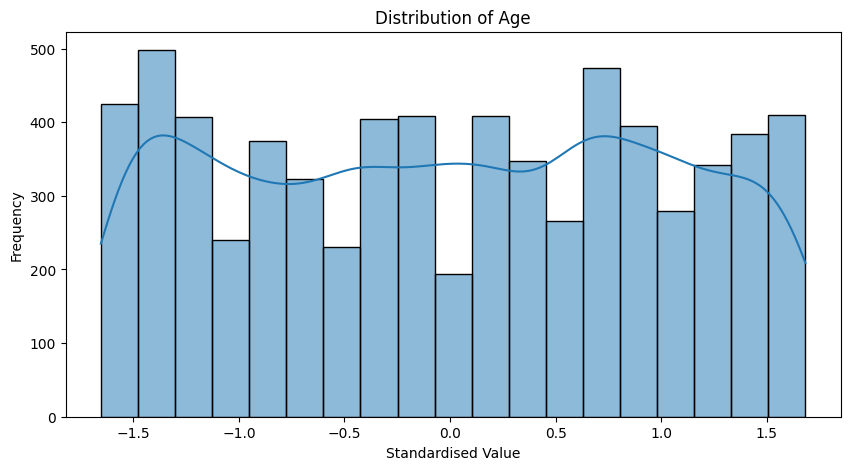

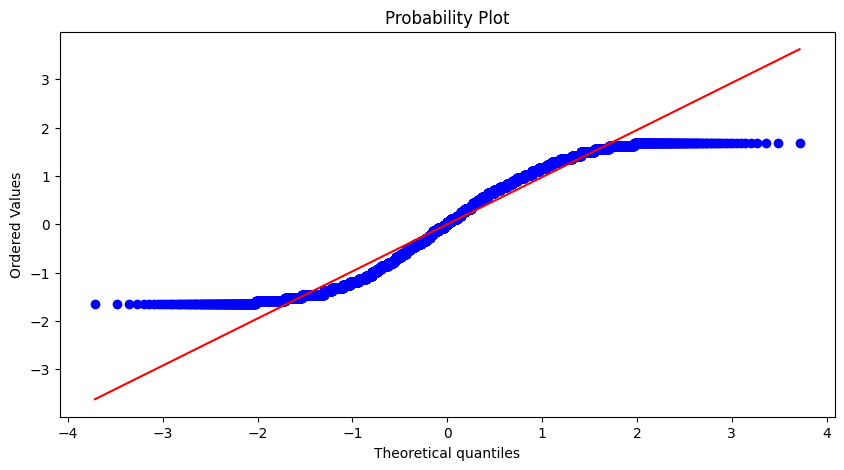

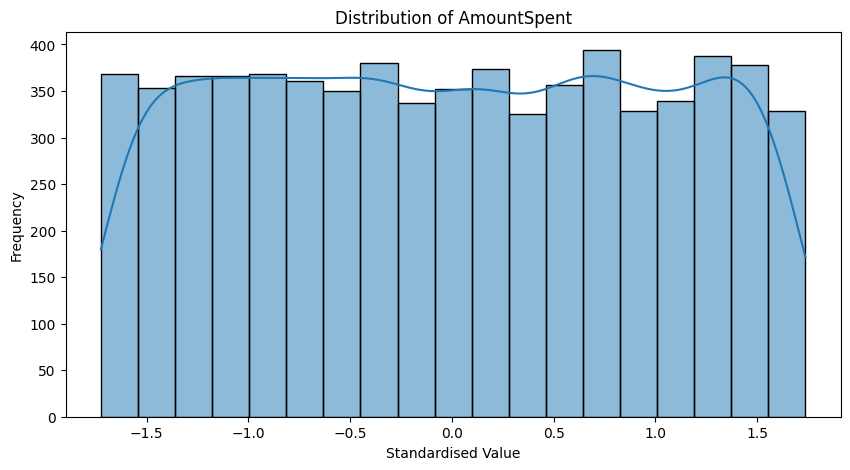

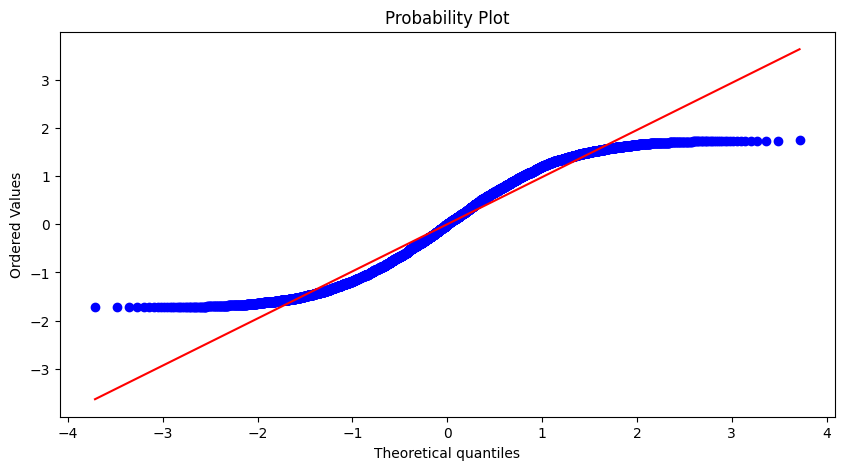

In [99]:
import scipy.stats as stats 

#create function to automate the check and test for normality of columns
def normal_displot_test(data, columns):
    """
    Normalizes specified columns and plots histograms and Q-Q plots to check for normality.

    Parameters:
    - data (pd.DataFrame): The input DataFrame containing the data.
    - columns (list): List of column names to normalize and plot.

    Returns:
    - data (pd.DataFrame): DataFrame with new columns for normalized values.
    """
    scaler = StandardScaler() 
    
    for feature in columns:
        # Normalise Data
        normalised_column = f"{feature}_scaled"
        data[normalised_column] = scaler.fit_transform(data[[feature]])
        
        # Plot Histogram with kde
        plt.figure(figsize=(10,5))
        sns.histplot(data[normalised_column], kde=True)
        plt.title(f"Distribution of {feature}")
        plt.xlabel("Standardised Value")
        plt.ylabel("Frequency")
        plt.show()
        
        #Q-Q Plot to test Guassian Distribution
        plt.figure(figsize=(10,5))
        stats.probplot(data[normalised_column], dist="norm", plot=plt)


data = df.copy()
#columns = ["Age", "AmountSpent"]
normalised_features = normal_displot_test(data,["Age", "AmountSpent"])

In [100]:
df

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionFrequency,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363.0,2022-03-31,Inquiry,Resolved,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329.0,2022-03-17,Inquiry,Resolved,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329.0,2022-03-17,Inquiry,Resolved,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329.0,2022-03-17,Inquiry,Resolved,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329.0,2022-03-17,Inquiry,Resolved,5,Website,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,1000,34,M,Widowed,Low,2724,2022-09-08,232.06,Groceries,NaN,NaT,NaN,NaN,22,Mobile App,0
6808,1000,34,M,Widowed,Low,2917,2022-12-13,324.98,Books,NaN,NaT,NaN,NaN,22,Mobile App,0
6809,1000,34,M,Widowed,Low,2979,2022-06-15,375.34,Groceries,NaN,NaT,NaN,NaN,22,Mobile App,0
6810,1000,34,M,Widowed,Low,8594,2022-04-08,166.73,Books,NaN,NaT,NaN,NaN,22,Mobile App,0


In [101]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define Categorical Data
categorical_features_ohe = ["Gender", "MaritalStatus", "ServiceUsage"]
categorical_features_ode = ["IncomeLevel"]
income_level = [["Low", "Medium", "High"]]

#Define Numerical Data
numerical_features_ss = ["Age", "AmountSpent", "LoginFrequency", "TransactionFrequency"] 
# numerical_features_mm = ["InteractionCount", "ComplaintCount", "FeedbackCount",	"InquiryCount",	"ResolvedCount", "UnresolvedCount"] ignore as values are specific at 0,1,2


# set encoders
ohe =  OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ode = OrdinalEncoder(categories=income_level)
log_transformer = FunctionTransformer(np.log1p)

# Preprocessor 
preprocessor = ColumnTransformer(transformers=[    ("onehot",ohe,categorical_features_ohe),
    ("ordinal", ode,categorical_features_ode),
    ("standard", StandardScaler(), numerical_features_ss),
    ("log", log_transformer, ["AmountSpent"])
])# Pipeline
pipeline = Pipeline(steps = [("preprocessor",preprocessor)])


In [106]:
from sklearn.model_selection import train_test_split
X = df.drop(columns="ChurnStatus")
y = df["ChurnStatus"]

# Split into train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

# fit pipeline
data=["X_train = pipeline.fit_transform(X_train)"]
data=["X_test = pipeline.transform(X_test)"]

smote =SMOTE(random_state=42)
data=["X_train, y_train = smote.fit_resample(X_train, y_train)"]

In [134]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# 1. قراءة البيانات من ملف الـ Excel (افترض أنه في نفس المسار)
file_path = 'Customer_Churn_Data_Large.xlsx'

customer_demographics = pd.read_excel(file_path, sheet_name='Customer_Demographics')
transaction_history = pd.read_excel(file_path, sheet_name='Transaction_History')
customer_service = pd.read_excel(file_path, sheet_name='Customer_Service')
online_activity = pd.read_excel(file_path, sheet_name='Online_Activity')
churn_status = pd.read_excel(file_path, sheet_name='Churn_Status')

# 2. تجميع البيانات لكل عميل

# --- المعاملات (Transactions) ---
transaction_agg = transaction_history.groupby('CustomerID').agg(
    Total_Spent=('AmountSpent', 'sum'),
    Avg_Spent=('AmountSpent', 'mean'),
    Transaction_Count=('TransactionID', 'count'),
    Unique_Categories=('ProductCategory', 'nunique')
).reset_index()

# --- خدمة العملاء (Customer Service) ---
# حساب عدد الشكاوى التي لم تحل لكل عميل
service_agg = customer_service.groupby('CustomerID').agg(
    Total_Interactions=('InteractionID', 'count'),
    Unresolved_Count=('ResolutionStatus', lambda x: (x == 'Unresolved').sum())
).reset_index()

# --- النشاط الرقمي (Online Activity) ---
# تحويل تاريخ آخر دخول إلى عدد الأيام الماضية (بافتراض أن تاريخ اليوم هو آخر تاريخ في البيانات)
# هذا مثال مبسط، في الواقع ستحتاج إلى تاريخ محدد كمرجع
online_activity['LastLoginDate'] = pd.to_datetime(online_activity['LastLoginDate'])
latest_date = online_activity['LastLoginDate'].max() # افترض أن هذا تاريخ التحليل
online_activity['DaysSinceLastLogin'] = (latest_date - online_activity['LastLoginDate']).dt.days

online_agg = online_activity[['CustomerID', 'LoginFrequency', 'DaysSinceLastLogin', 'ServiceUsage']].copy()

# --- الديموغرافيا (Demographics) ---
# تحويل المتغيرات النصية إلى أرقام (Label Encoding)
demo_encoded = customer_demographics.copy()
label_enc_gender = LabelEncoder()
label_enc_marital = LabelEncoder()
label_enc_income = LabelEncoder()

demo_encoded['Gender_Enc'] = label_enc_gender.fit_transform(demo_encoded['Gender'])
demo_encoded['MaritalStatus_Enc'] = label_enc_marital.fit_transform(demo_encoded['MaritalStatus'])
demo_encoded['IncomeLevel_Enc'] = label_enc_income.fit_transform(demo_encoded['IncomeLevel'])

demo_agg = demo_encoded[['CustomerID', 'Age', 'Gender_Enc', 'MaritalStatus_Enc', 'IncomeLevel_Enc']]

# --- دمج جميع الجداول في جدول رئيسي واحد ---
master_df = churn_status.copy()
master_df = master_df.merge(demo_agg, on='CustomerID', how='left')
master_df = master_df.merge(transaction_agg, on='CustomerID', how='left')
master_df = master_df.merge(service_agg, on='CustomerID', how='left')
master_df = master_df.merge(online_agg, on='CustomerID', how='left')

# معالجة القيم المفقودة (NaN) التي قد تنتج عن عملاء ليس لديهم معاملات أو اتصالات
master_df.fillna({
    'Total_Spent': 0, 'Avg_Spent': 0, 'Transaction_Count': 0, 'Unique_Categories': 0,
    'Total_Interactions': 0, 'Unresolved_Count': 0,
    'LoginFrequency': 0, 'DaysSinceLastLogin': 365, 'ServiceUsage': 'Unknown'
}, inplace=True)

# ترميز ServiceUsage
master_df['ServiceUsage_Enc'] = label_enc_gender.fit_transform(master_df['ServiceUsage']) # معادة استخدام الـ Encoder

# 3. إعداد البيانات للنموذج

# اختيار الأعمدة التي ستكون خصائص (Features)
features = ['Age', 'Gender_Enc', 'MaritalStatus_Enc', 'IncomeLevel_Enc',
            'Total_Spent', 'Avg_Spent', 'Transaction_Count', 'Unique_Categories',
            'Total_Interactions', 'Unresolved_Count',
            'LoginFrequency', 'DaysSinceLastLogin', 'ServiceUsage_Enc']

X = master_df[features]
y = master_df['ChurnStatus']

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. بناء وتدريب نموذج الانحدار اللوجستي
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 5. تقييم النموذج
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # الاحتمالات للفئة 1 (Churn)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

# 6. (اختياري) عرض أهمية الخصائص
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop Features by Coefficient (Higher = More impact on Churn):")
print(feature_importance)

Confusion Matrix:
[[150   0]
 [ 50   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       150
           1       0.00      0.00      0.00        50

    accuracy                           0.75       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.56      0.75      0.64       200


ROC-AUC Score: 0.471

Top Features by Coefficient (Higher = More impact on Churn):
               Feature  Coefficient
9     Unresolved_Count     0.126126
6    Transaction_Count     0.081082
1           Gender_Enc     0.065181
3      IncomeLevel_Enc     0.030810
7    Unique_Categories     0.023832
0                  Age     0.009109
5            Avg_Spent     0.002407
11  DaysSinceLastLogin     0.000511
4          Total_Spent    -0.000307
8   Total_Interactions    -0.010639
2    MaritalStatus_Enc    -0.019130
10      LoginFrequency    -0.022925
12    ServiceUsage_Enc    -0.039106


Loading data...
Loaded 1000 customers

Processing data...
Rows after merging: 1000
Number of columns: 18

Available columns:
['CustomerID', 'ChurnStatus', 'Age', 'Gender_Enc', 'MaritalStatus_Enc', 'IncomeLevel_Enc', 'Transaction_Count', 'Total_Spent', 'Avg_Spent', 'Std_Spent', 'Product_Diversity', 'Total_Interactions', 'Unresolved_Count', 'Unresolved_Ratio', 'LoginFrequency', 'DaysSinceLastLogin', 'ServiceUsage', 'ServiceUsage_Enc']

Number of features: 15
Target variable distribution:
ChurnStatus
0    796
1    204
Name: count, dtype: int64
Churn rate: 20.40%

Training data size: (800, 15)
Testing data size: (200, 15)

Starting model training and evaluation...

--- Logistic Regression ---
Accuracy: 0.7950
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC: 0.5502

--- Decision Tree ---
Accuracy: 0.7550
Precision: 0.3000
Recall: 0.1463
F1 Score: 0.1967
ROC AUC: 0.5257

--- Random Forest ---
Accuracy: 0.7900
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC: 0.5076

--- Gr

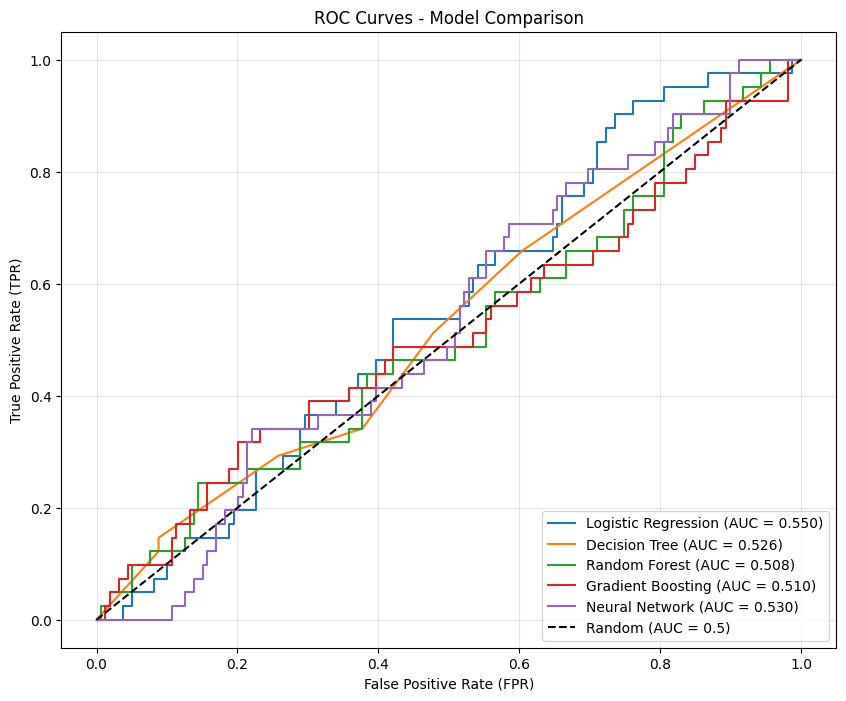


Model Performance Comparison Table:
              Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
Logistic Regression     0.795   0.000000 0.000000  0.000000 0.550238
      Decision Tree     0.755   0.300000 0.146341  0.196721 0.525694
      Random Forest     0.790   0.000000 0.000000  0.000000 0.507593
  Gradient Boosting     0.775   0.300000 0.073171  0.117647 0.509587
     Neural Network     0.710   0.052632 0.024390  0.033333 0.529682


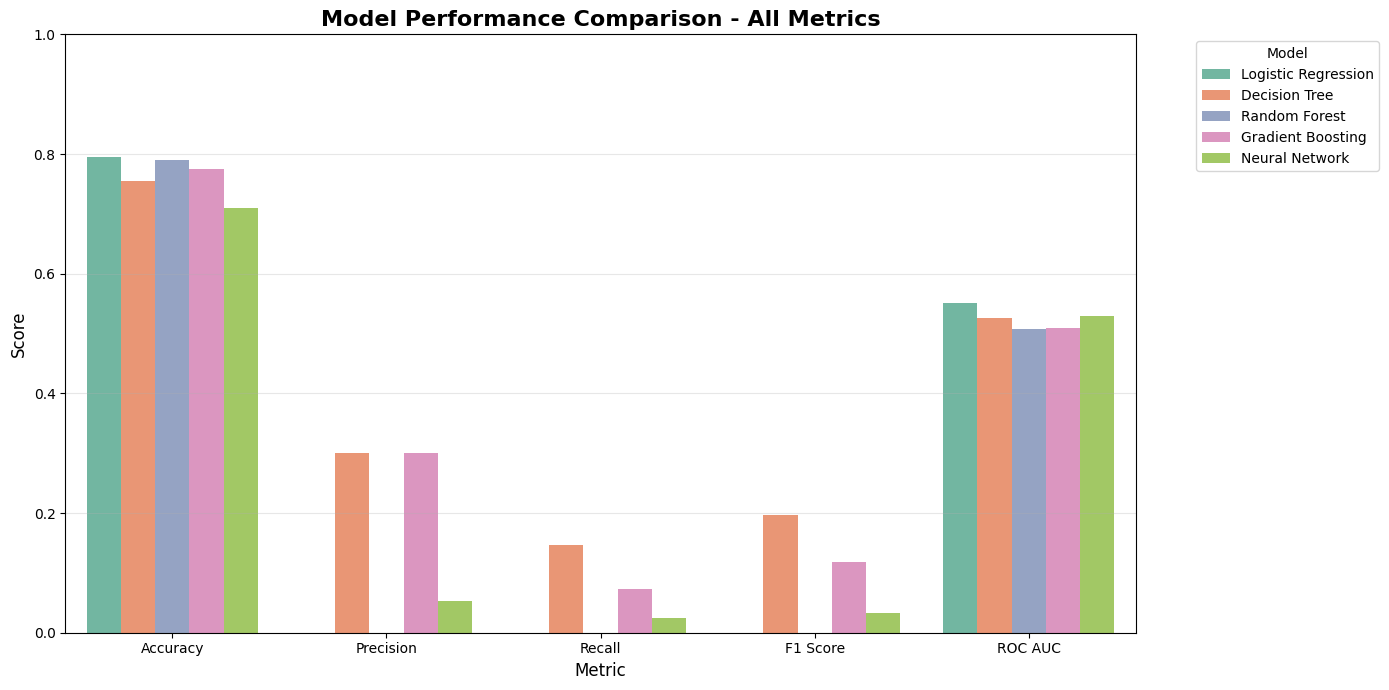


 Best Model based on F1 Score:
Model: Decision Tree
Accuracy: 0.7550
Precision: 0.3000
Recall: 0.1463
F1 Score: 0.1967
ROC AUC: 0.5257


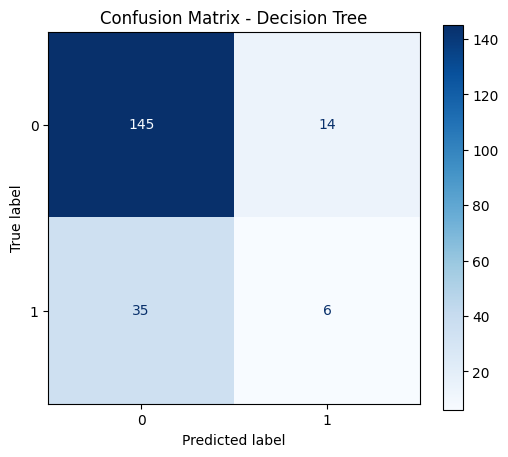


 Analysis completed successfully!


In [136]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. Load Data from Excel File
# ============================================
file_path = 'Customer_Churn_Data_Large.xlsx'  # Make sure the path is correct

print("Loading data...")
customer_demographics = pd.read_excel(file_path, sheet_name='Customer_Demographics')
transaction_history = pd.read_excel(file_path, sheet_name='Transaction_History')
customer_service = pd.read_excel(file_path, sheet_name='Customer_Service')
online_activity = pd.read_excel(file_path, sheet_name='Online_Activity')
churn_status = pd.read_excel(file_path, sheet_name='Churn_Status')

print(f"Loaded {len(customer_demographics)} customers")

# ============================================
# 2. Data Processing and Feature Engineering
# ============================================

print("\nProcessing data...")

# ----- A. Transaction Processing -----
transaction_agg = transaction_history.groupby('CustomerID').agg({
    'TransactionID': 'count',  # number of transactions
    'AmountSpent': ['sum', 'mean', 'std']  # total, average, and standard deviation of transactions
}).reset_index()

# flatten column names
transaction_agg.columns = ['CustomerID', 'Transaction_Count', 'Total_Spent', 'Avg_Spent', 'Std_Spent']
transaction_agg['Std_Spent'] = transaction_agg['Std_Spent'].fillna(0)  # for customers with only one transaction

# Product diversity
product_diversity = transaction_history.groupby('CustomerID')['ProductCategory'].nunique().reset_index()
product_diversity.columns = ['CustomerID', 'Product_Diversity']
transaction_agg = transaction_agg.merge(product_diversity, on='CustomerID', how='left')

# ----- B. Customer Service Processing -----
service_agg = customer_service.groupby('CustomerID').agg({
    'InteractionID': 'count',  # total interactions
    'ResolutionStatus': lambda x: (x == 'Unresolved').sum()  # number of unresolved issues
}).reset_index()
service_agg.columns = ['CustomerID', 'Total_Interactions', 'Unresolved_Count']
service_agg['Unresolved_Ratio'] = service_agg['Unresolved_Count'] / service_agg['Total_Interactions']
service_agg['Unresolved_Ratio'] = service_agg['Unresolved_Ratio'].fillna(0)  # for customers with no interactions

# ----- C. Online Activity Processing -----
online_activity['LastLoginDate'] = pd.to_datetime(online_activity['LastLoginDate'])
# Calculate days since last login (assuming latest date is 2023-12-31)
reference_date = pd.to_datetime('2023-12-31')
online_activity['DaysSinceLastLogin'] = (reference_date - online_activity['LastLoginDate']).dt.days

online_agg = online_activity[['CustomerID', 'LoginFrequency', 'DaysSinceLastLogin', 'ServiceUsage']].copy()

# Encode ServiceUsage
le_service = LabelEncoder()
online_agg['ServiceUsage_Enc'] = le_service.fit_transform(online_agg['ServiceUsage'])

# ----- D. Demographics Processing -----
# Encode categorical variables
le_gender = LabelEncoder()
le_marital = LabelEncoder()
le_income = LabelEncoder()

customer_demographics['Gender_Enc'] = le_gender.fit_transform(customer_demographics['Gender'])
customer_demographics['MaritalStatus_Enc'] = le_marital.fit_transform(customer_demographics['MaritalStatus'])
customer_demographics['IncomeLevel_Enc'] = le_income.fit_transform(customer_demographics['IncomeLevel'])

demo_agg = customer_demographics[['CustomerID', 'Age', 'Gender_Enc', 'MaritalStatus_Enc', 'IncomeLevel_Enc']]

# ============================================
# 3. Merge All Data into One DataFrame
# ============================================

master_df = churn_status.copy()
master_df = master_df.merge(demo_agg, on='CustomerID', how='left')
master_df = master_df.merge(transaction_agg, on='CustomerID', how='left')
master_df = master_df.merge(service_agg, on='CustomerID', how='left')
master_df = master_df.merge(online_agg, on='CustomerID', how='left')

# Fill missing values
master_df.fillna({
    'Transaction_Count': 0,
    'Total_Spent': 0,
    'Avg_Spent': 0,
    'Std_Spent': 0,
    'Product_Diversity': 0,
    'Total_Interactions': 0,
    'Unresolved_Count': 0,
    'Unresolved_Ratio': 0,
    'LoginFrequency': 0,
    'DaysSinceLastLogin': 365,
    'ServiceUsage_Enc': 0
}, inplace=True)

print(f"Rows after merging: {len(master_df)}")
print(f"Number of columns: {len(master_df.columns)}")
print("\nAvailable columns:")
print(master_df.columns.tolist())

# ============================================
# 4. Select Features and Target Variable
# ============================================

# Select appropriate features
feature_columns = [
    'Age', 'Gender_Enc', 'MaritalStatus_Enc', 'IncomeLevel_Enc',
    'Transaction_Count', 'Total_Spent', 'Avg_Spent', 'Std_Spent', 'Product_Diversity',
    'Total_Interactions', 'Unresolved_Count', 'Unresolved_Ratio',
    'LoginFrequency', 'DaysSinceLastLogin', 'ServiceUsage_Enc'
]

X = master_df[feature_columns]
y = master_df['ChurnStatus']

print(f"\nNumber of features: {len(feature_columns)}")
print(f"Target variable distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.2f}%")

# ============================================
# 5. Split Data and Normalize
# ============================================

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

# Normalize data (important for models like Logistic Regression and Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 6. Define Models
# ============================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=100),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=42, hidden_layer_sizes=(100, 50))
}

# ============================================
# 7. Train and Evaluate Models
# ============================================

results = []
plt.figure(figsize=(10, 8))

print("\n" + "="*60)
print("Starting model training and evaluation...")
print("="*60)

for model_name, model in models.items():
    print(f"\n--- {model_name} ---")
    
    # Train the model
    if model_name in ["Logistic Regression", "Neural Network"]:
        model.fit(X_train_scaled, y_train)
        X_test_used = X_test_scaled
    else:
        model.fit(X_train, y_train)
        X_test_used = X_test
    
    # Predict
    y_pred = model.predict(X_test_used)
    y_proba = model.predict_proba(X_test_used)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })
    
    # Print classification report
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}" if roc_auc else "ROC AUC: Not available")
    
    # Plot ROC curve
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

# ============================================
# 8. Display Results
# ============================================

# Plot ROC curve
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves - Model Comparison")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Display model comparison table
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("Model Performance Comparison Table:")
print("="*60)
print(results_df.to_string(index=False))

# ============================================
# 9. Bar Chart for Model Comparison
# ============================================

# Prepare data for plotting
results_melted = results_df.melt(
    id_vars="Model", 
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=results_melted, 
    x="variable", 
    y="value", 
    hue="Model",
    palette="Set2"
)
plt.title("Model Performance Comparison - All Metrics", fontsize=16, fontweight='bold')
plt.ylabel("Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================
# 10. Display Best Model
# ============================================

best_model = results_df.loc[results_df['F1 Score'].idxmax()]
print("\n" + "="*60)
print(" Best Model based on F1 Score:")
print("="*60)
print(f"Model: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall: {best_model['Recall']:.4f}")
print(f"F1 Score: {best_model['F1 Score']:.4f}")
print(f"ROC AUC: {best_model['ROC AUC']:.4f}")

# ============================================
# 11. Optional: Display Confusion Matrix for Best Model
# ============================================

# Retrain the best model to show confusion matrix
best_model_name = best_model['Model']
best_model_obj = models[best_model_name]

if best_model_name in ["Logistic Regression", "Neural Network"]:
    best_model_obj.fit(X_train_scaled, y_train)
    X_test_best = X_test_scaled
else:
    best_model_obj.fit(X_train, y_train)
    X_test_best = X_test

y_pred_best = best_model_obj.predict(X_test_best)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print("\n Analysis completed successfully!")

Loading data...
Loaded 1000 customers

Processing data...

Merged data shape: (1000, 18)
Columns: ['CustomerID', 'ChurnStatus', 'Age', 'Gender_Enc', 'MaritalStatus_Enc', 'IncomeLevel_Enc', 'Transaction_Count', 'Total_Spent', 'Avg_Spent', 'Std_Spent', 'Product_Diversity', 'Total_Interactions', 'Unresolved_Count', 'Unresolved_Ratio', 'LoginFrequency', 'DaysSinceLastLogin', 'ServiceUsage', 'ServiceUsage_Enc']

Number of features: 15
Features: ['Age', 'Gender_Enc', 'MaritalStatus_Enc', 'IncomeLevel_Enc', 'Transaction_Count', 'Total_Spent', 'Avg_Spent', 'Std_Spent', 'Product_Diversity', 'Total_Interactions', 'Unresolved_Count', 'Unresolved_Ratio', 'LoginFrequency', 'DaysSinceLastLogin', 'ServiceUsage_Enc']

Target distribution:
ChurnStatus
0    796
1    204
Name: count, dtype: int64
Churn rate: 20.40%

Training set size: (800, 15)
Testing set size: (200, 15)

Training Random Forest model...

Model Performance:
Accuracy: 0.7900
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC: 0.507

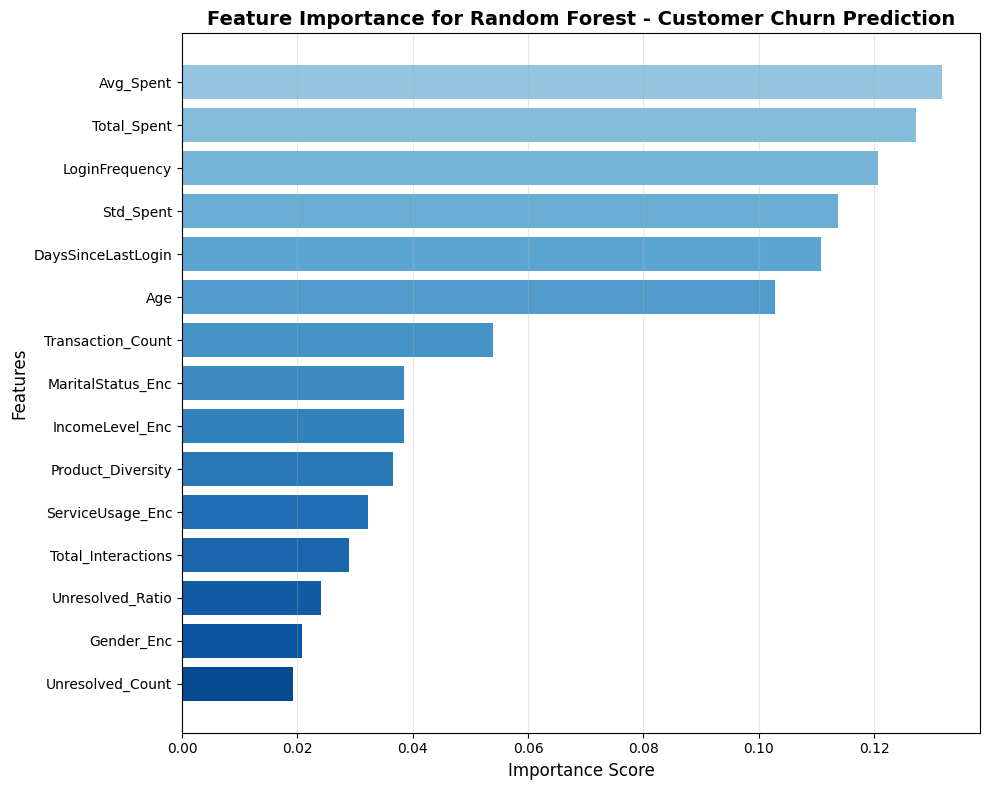

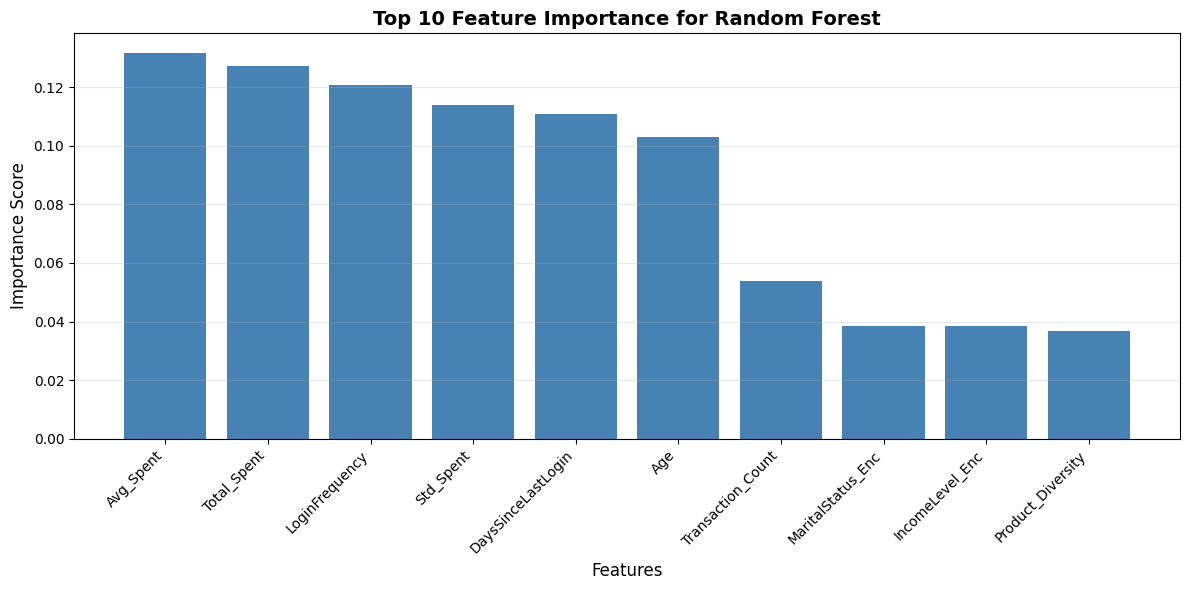


 Feature importance saved to 'feature_importance_random_forest.csv'

Cumulative Feature Importance
1. Avg_Spent: 0.1318 (Cumulative: 0.1318)
2. Total_Spent: 0.1272 (Cumulative: 0.2590)
3. LoginFrequency: 0.1207 (Cumulative: 0.3797)
4. Std_Spent: 0.1138 (Cumulative: 0.4935)
5. DaysSinceLastLogin: 0.1107 (Cumulative: 0.6042)
6. Age: 0.1028 (Cumulative: 0.7070)
7. Transaction_Count: 0.0540 (Cumulative: 0.7610)
8. MaritalStatus_Enc: 0.0384 (Cumulative: 0.7995)
9. IncomeLevel_Enc: 0.0384 (Cumulative: 0.8379)
10. Product_Diversity: 0.0366 (Cumulative: 0.8745)

 9 features are needed to reach 80% cumulative importance


In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================
# 1. Load Data from Excel File
# ============================================
file_path = 'Customer_Churn_Data_Large.xlsx'

print("Loading data...")
customer_demographics = pd.read_excel(file_path, sheet_name='Customer_Demographics')
transaction_history = pd.read_excel(file_path, sheet_name='Transaction_History')
customer_service = pd.read_excel(file_path, sheet_name='Customer_Service')
online_activity = pd.read_excel(file_path, sheet_name='Online_Activity')
churn_status = pd.read_excel(file_path, sheet_name='Churn_Status')

print(f"Loaded {len(customer_demographics)} customers")

# ============================================
# 2. Data Processing and Feature Engineering
# ============================================

print("\nProcessing data...")

# ----- A. Transaction Processing -----
transaction_agg = transaction_history.groupby('CustomerID').agg({
    'TransactionID': 'count',  # number of transactions
    'AmountSpent': ['sum', 'mean', 'std']  # total, average, and standard deviation
}).reset_index()

# Flatten column names
transaction_agg.columns = ['CustomerID', 'Transaction_Count', 'Total_Spent', 'Avg_Spent', 'Std_Spent']
transaction_agg['Std_Spent'] = transaction_agg['Std_Spent'].fillna(0)  # for customers with only one transaction

# Product diversity
product_diversity = transaction_history.groupby('CustomerID')['ProductCategory'].nunique().reset_index()
product_diversity.columns = ['CustomerID', 'Product_Diversity']
transaction_agg = transaction_agg.merge(product_diversity, on='CustomerID', how='left')

# ----- B. Customer Service Processing -----
service_agg = customer_service.groupby('CustomerID').agg({
    'InteractionID': 'count',  # total interactions
    'ResolutionStatus': lambda x: (x == 'Unresolved').sum()  # number of unresolved issues
}).reset_index()
service_agg.columns = ['CustomerID', 'Total_Interactions', 'Unresolved_Count']
service_agg['Unresolved_Ratio'] = service_agg['Unresolved_Count'] / service_agg['Total_Interactions']
service_agg['Unresolved_Ratio'] = service_agg['Unresolved_Ratio'].fillna(0)

# ----- C. Online Activity Processing -----
online_activity['LastLoginDate'] = pd.to_datetime(online_activity['LastLoginDate'])
# Calculate days since last login (assuming latest date is 2023-12-31)
reference_date = pd.to_datetime('2023-12-31')
online_activity['DaysSinceLastLogin'] = (reference_date - online_activity['LastLoginDate']).dt.days

online_agg = online_activity[['CustomerID', 'LoginFrequency', 'DaysSinceLastLogin', 'ServiceUsage']].copy()

# Encode ServiceUsage
le_service = LabelEncoder()
online_agg['ServiceUsage_Enc'] = le_service.fit_transform(online_agg['ServiceUsage'])

# ----- D. Demographics Processing -----
# Encode categorical variables
le_gender = LabelEncoder()
le_marital = LabelEncoder()
le_income = LabelEncoder()

customer_demographics['Gender_Enc'] = le_gender.fit_transform(customer_demographics['Gender'])
customer_demographics['MaritalStatus_Enc'] = le_marital.fit_transform(customer_demographics['MaritalStatus'])
customer_demographics['IncomeLevel_Enc'] = le_income.fit_transform(customer_demographics['IncomeLevel'])

demo_agg = customer_demographics[['CustomerID', 'Age', 'Gender_Enc', 'MaritalStatus_Enc', 'IncomeLevel_Enc']]

# ============================================
# 3. Merge All Data into One DataFrame
# ============================================

master_df = churn_status.copy()
master_df = master_df.merge(demo_agg, on='CustomerID', how='left')
master_df = master_df.merge(transaction_agg, on='CustomerID', how='left')
master_df = master_df.merge(service_agg, on='CustomerID', how='left')
master_df = master_df.merge(online_agg, on='CustomerID', how='left')

# Fill missing values
master_df.fillna({
    'Transaction_Count': 0,
    'Total_Spent': 0,
    'Avg_Spent': 0,
    'Std_Spent': 0,
    'Product_Diversity': 0,
    'Total_Interactions': 0,
    'Unresolved_Count': 0,
    'Unresolved_Ratio': 0,
    'LoginFrequency': 0,
    'DaysSinceLastLogin': 365,
    'ServiceUsage_Enc': 0
}, inplace=True)

print(f"\nMerged data shape: {master_df.shape}")
print(f"Columns: {master_df.columns.tolist()}")

# ============================================
# 4. Select Features and Target Variable
# ============================================

# Select features
feature_columns = [
    'Age', 'Gender_Enc', 'MaritalStatus_Enc', 'IncomeLevel_Enc',
    'Transaction_Count', 'Total_Spent', 'Avg_Spent', 'Std_Spent', 'Product_Diversity',
    'Total_Interactions', 'Unresolved_Count', 'Unresolved_Ratio',
    'LoginFrequency', 'DaysSinceLastLogin', 'ServiceUsage_Enc'
]

X = master_df[feature_columns]  # Features
y = master_df['ChurnStatus']     # Target variable

print(f"\nNumber of features: {len(feature_columns)}")
print(f"Features: {feature_columns}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.2f}%")

# ============================================
# 5. Train Random Forest Model
# ============================================

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Train Random Forest model
print("\nTraining Random Forest model...")
best_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
best_model.fit(X_train, y_train)

# Make predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# ============================================
# 6. Feature Importance Visualization (Your Requested Code)
# ============================================

print("\n" + "="*60)
print("Feature Importance Analysis for Random Forest")
print("="*60)

# Get feature importances from the trained model
feature_importances = best_model.feature_importances_
feature_names = X.columns  # X is your feature DataFrame

# Create DataFrame with feature names and their importance scores
feature_importance_df = pd.DataFrame({
    "Feature": feature_names, 
    "Importance": feature_importances
})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Display top 10 features
print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10).to_string(index=False))

# Plot feature importance (horizontal bar chart)
plt.figure(figsize=(10, 8))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(feature_importance_df)))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color=colors)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title("Feature Importance for Random Forest - Customer Churn Prediction", fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Display highest importance at the top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 7. Alternative Visualization (Vertical Bar Chart)
# ============================================

# Plot top 10 features only (vertical bar chart for better readability)
plt.figure(figsize=(12, 6))
top_10_features = feature_importance_df.head(10)
plt.bar(top_10_features["Feature"], top_10_features["Importance"], color='steelblue')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)
plt.title("Top 10 Feature Importance for Random Forest", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 8. Save feature importance to CSV (optional)
# ============================================

feature_importance_df.to_csv('feature_importance_random_forest.csv', index=False)
print("\n Feature importance saved to 'feature_importance_random_forest.csv'")

# ============================================
# 9. Additional Analysis: Cumulative Importance
# ============================================

# Calculate cumulative importance
feature_importance_df['Cumulative_Importance'] = feature_importance_df['Importance'].cumsum()

print("\n" + "="*60)
print("Cumulative Feature Importance")
print("="*60)
for i in range(min(10, len(feature_importance_df))):
    print(f"{i+1}. {feature_importance_df.iloc[i]['Feature']}: "
          f"{feature_importance_df.iloc[i]['Importance']:.4f} "
          f"(Cumulative: {feature_importance_df.iloc[i]['Cumulative_Importance']:.4f})")

# Find how many features are needed to reach 80% importance
features_needed = (feature_importance_df['Cumulative_Importance'] <= 0.8).sum() + 1
print(f"\n {features_needed} features are needed to reach 80% cumulative importance")


